In [1]:
import Pkg
Pkg.activate(".")

  Activating project at `/global/u1/b/blaschke/NESAP/GB-25-2026/analysis`


In [2]:
using GBAnalyzer, Plots

[ Info: Precompiling GBAnalyzer [bc4d49b3-fbc7-4081-9e3d-3495df270036] (cache misses: include_dependency fsize change (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [8]:
comm_opt = GBAnalyzer.summarize_run_dirs(
    "/global/cfs/cdirs/m5176/roman/GB25/2026.04.11.gb_re_26_1/ocean/scaling/comm_opts", "loop2"
)
keys(comm_opt)

KeySet for a Dict{String, Vector{GBAnalyzer.Run}} with 1 entry. Keys:
  "sharded_baroclinic_instability_simulation_run.jl"

In [9]:
ablation_tests = GBAnalyzer.summarize_run_dirs(
    "/global/cfs/cdirs/m5176/roman/GB25/2026.04.11.gb_re_26_1/ocean/scaling/ablation", "loop2"
)
keys(ablation_tests)

KeySet for a Dict{String, Vector{GBAnalyzer.Run}} with 1 entry. Keys:
  "sharded_baroclinic_instability_simulation_run.jl"

In [13]:
job_table_co = comm_opt["sharded_baroclinic_instability_simulation_run.jl"] |> filter(x->sum(x.prof)>0)
sort!(job_table_co, by=x->x.time, rev=true)
GBAnalyzer.summary_table(job_table_co)

╭─────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬───┬───┬────┬────┬─────┬─────┬─────┬─────┬──────┬──────╮
│ idx │                                                                                                               run │ 4 │ 8 │ 32 │ 72 │ 128 │ 288 │ 512 │ 968 │ 2048 │ 3872 │
├─────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼───┼───┼────┼────┼─────┼─────┼─────┼─────┼──────┼──────┤
│   1 │ /global/cfs/cdirs/m5176/roman/GB25/2026.04.11.gb_re_26_1/ocean/scaling/comm_opts/2026-04-11T17-00-24.828_ngpu3872 │ 1 │ 1 │  1 │  1 │   1 │   1 │   1 │   1 │    1 │    1 │
╰─────┴───────────────────────────────────────────────────────────────────────────────────────────────────────────────────┴───┴───┴────┴────┴─────┴─────┴─────┴─────┴──────┴──────╯


In [14]:
job_table_ab = ablation_tests["sharded_baroclinic_instability_simulation_run.jl"] |> filter(x->sum(x.prof)>0)
sort!(job_table_ab, by=x->x.time, rev=true)
GBAnalyzer.summary_table(job_table_ab)

╭─────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬───┬───┬────┬────┬─────┬─────┬─────┬─────┬──────╮
│ idx │                                                                                                              run │ 4 │ 8 │ 32 │ 72 │ 128 │ 288 │ 512 │ 968 │ 2048 │
├─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼───┼───┼────┼────┼─────┼─────┼─────┼─────┼──────┤
│   1 │ /global/cfs/cdirs/m5176/roman/GB25/2026.04.11.gb_re_26_1/ocean/scaling/ablation/2026-04-11T16-08-21.868_ngpu2048 │ 1 │ 1 │  1 │  0 │   1 │   1 │   1 │   0 │    1 │
╰─────┴──────────────────────────────────────────────────────────────────────────────────────────────────────────────────┴───┴───┴────┴────┴─────┴─────┴─────┴─────┴──────╯


In [15]:
run_metrics_co = Dict()

for elt in job_table_co
    for ngpu in elt.prof
        jid   = GBAnalyzer.get_jobid(
            joinpath(elt.path, GBAnalyzer.test_dir(ngpu))
        )
        # TODO: Don't just use MPI Rank 0 -- but instead:
        # 1. find out how many ranks there are,
        # 2. Average over those ranks
        pdir  = GBAnalyzer.profile_dir(elt.path, jid, 0; prof_dir="loop2")
        tpath = GBAnalyzer.profile_for_job(pdir)
        st, _ = GBAnalyzer.get_run_stats(tpath)
        for metric in keys(st)
            push!(
                get!(run_metrics_co, metric, []),
                (mean=st[metric].mean, sum=st[metric].sum, ngpu=ngpu)
            )
        end
    end
end

run_metrics_ab = Dict()

for elt in job_table_ab
    for ngpu in elt.prof
        jid   = GBAnalyzer.get_jobid(
            joinpath(elt.path, GBAnalyzer.test_dir(ngpu))
        )
        # TODO: Don't just use MPI Rank 0 -- but instead:
        # 1. find out how many ranks there are,
        # 2. Average over those ranks
        pdir  = GBAnalyzer.profile_dir(elt.path, jid, 0; prof_dir="loop2")
        tpath = GBAnalyzer.profile_for_job(pdir)
        st, _ = GBAnalyzer.get_run_stats(tpath)
        for metric in keys(st)
            push!(
                get!(run_metrics_ab, metric, []),
                (mean=st[metric].mean, sum=st[metric].sum, ngpu=ngpu)
            )
        end
    end
end

In [22]:
metric_keys = union(Set(keys(run_metrics_co)), Set(keys(run_metrics_ab))) |> collect

5017-element Vector{Any}:
 "all-gather-done.5"
 "all-to-all-done.73"
 "wrapped_slice_501"
 "loop_subtract_fusion.12"
 "loop_slice_fusion_191"
 "all-to-all.37.1"
 "command_buffer_1428"
 "input_concatenate_fusion.143"
 "loop_add_fusion.37"
 "command_buffer_142"
 "command_buffer_724"
 "command_buffer_346"
 "wrapped_slice.222"
 ⋮
 "wrapped_slice_153"
 "wrapped_concatenate.2"
 "all-to-all.282.1"
 "copy.892"
 "loop_multiply_fusion.13"
 "loop_slice_fusion_284"
 "all-to-all-start.42"
 "command_buffer_1887"
 "loop_slice_fusion_64"
 "wrapped_slice_160"
 "wrapped_slice_68"
 "loop_dynamic_slice_fusion_40"

In [28]:
nccl_metrics = metric_keys |> filter(startswith("nccl"))

collectives_metrics = vcat(
    metric_keys |> filter(startswith("all-to-all")),
    metric_keys |> filter(startswith("all-gather")),
    metric_keys |> filter(startswith("all-reduce")),
    metric_keys |> filter(startswith("collective-permute")),
    metric_keys |> filter(startswith("wrapped_broadcast"))
)

compute_slice_metrics = vcat(
    metric_keys |> filter(startswith("wrapped_slice")),
    metric_keys |> filter(startswith("wrapped_dynamic-slice")),
    metric_keys |> filter(startswith("wrapped_dynamic_slice")),
    metric_keys |> filter(startswith("input_slice"))
)

compute_loop_metrics = metric_keys |> filter(startswith("loop"))

compute_add_metrics = metric_keys |> filter(startswith("wrapped_add"))

compute_multiply_metrics = metric_keys |> filter(startswith("input_multiply_transpose"))

compute_concatenate_metrics = vcat(
    metric_keys |> filter(startswith("wrapped_concatenate")),
    metric_keys |> filter(startswith("input_concatenate"))
)

compute_transpose_metrics = vcat(
    metric_keys |> filter(startswith("input_transpose")),
    metric_keys |> filter(startswith("input_negate_transpose")),
    metric_keys |> filter(startswith("input_slice_transpose")),
    metric_keys |> filter(startswith("input_select_transpose")),
    metric_keys |> filter(startswith("input_compare_transpose_fusion")),
    metric_keys |> filter(startswith("input_select_slice_transpose_fusion"))   
)

compute_extra_metrics = vcat(
    metric_keys |> filter(startswith("Memset")),
    metric_keys |> filter(startswith("copy")),
    metric_keys |> filter(startswith("while")),
    metric_keys |> filter(startswith("wrapped_multiply")),
    metric_keys |> filter(startswith("wrapped_transpose")),
    [
        "wrapped_compare",
        "input_add_transpose_fusion",
        "wrapped_and",
        "wrapped_select"
    ]
)

compute_metrics = vcat(
    compute_slice_metrics,
    compute_loop_metrics,
    compute_add_metrics,
    compute_multiply_metrics,
    compute_concatenate_metrics,
    compute_transpose_metrics,
    compute_extra_metrics
)

cuda_api_metrics = [
    "cuStreamSynchronize",
    "MemcpyD2H",
    "MemcpyD2D"
]

cuda_api_memcpy_metrics = [
    "MemcpyD2H",
    "MemcpyD2D"
]

command_buffer_metrics = metric_keys |> filter(startswith("command_buffer"))

# Sanity checking to make sure that I dind't miss anything:

all_metrics = vcat(
    nccl_metrics,
    collectives_metrics,
    compute_metrics,
    cuda_api_memcpy_metrics,
    command_buffer_metrics
)

ignore_metrics = vcat(
    metric_keys |> filter(startswith("Wait")),
    metric_keys |> filter(startswith("ThreadpoolListener")),
    metric_keys |> filter(startswith("PjRtStreamExecutorLoadedExecutable")),
    metric_keys |> filter(startswith("Thunks")),
    metric_keys |> filter(startswith("reactant_loop_")),
    metric_keys |> filter(startswith("ComputeSemaphoreAcquire")),
    metric_keys |> filter(startswith("partition-id")),
    metric_keys |> filter(startswith("reactant_loop_")),
    metric_keys |> filter(endswith("CommonPjRtLoadedExecutable::Execute (reactant_loop_)")),
    metric_keys |> filter(endswith("PjRtStreamExecutorRawLoadedExecutable::Execute")),
    metric_keys |> filter(endswith("GpuExecutable::ExecuteThunks")),
    [
        "InvokeRendezvous",
        "While",
        "RecordUsage",
        "LockGpuClique", 
        "MakeOutputBuffers",
        "Lockable::Lock::Acquire",
        "ThenExecuteCallback",
        "Build buffer allocations",
        "RendezvousAfterInitialization",
        "Build buffer allocations",
        "ExecuteRendezvousCallback",
        "AllocateOutputBuffersWithInputReuse",
        "BUFFER_FLUSH",
        "AcquireCollectiveCliques",
        "ComputeSemaphoreAcquire",
        "CommonPjRtLoadedExecutable::ExecutePrepare",
        "Resolve constant globals",
        "AcquireGpuClique",
        "Rendezvous",
        "Handle inputs",
        "bench",
        "WARNING: CommandBuffer disabled when profiling",
        "<UNKNOWN>"
    ]
)

metric_keys                        |>
    filter(x->!(x in all_metrics)) |>
    filter(x->!(x in ignore_metrics))

Any[]

In [74]:
function sum_metrics(data, metrics)
    cm = Dict()
    
    for k in metrics
        if !(k in keys(data)) continue end
        d = data[k]
        x = map(x->x.ngpu, d)
        y = map(x->x.sum,  d)
        for (n, m) in zip(x, y)
            cm[n] = get!(cm, n, 0) + m
        end
    end
    
    x = cm |> keys |> collect |> sort
    y = map(x->cm[x], x)
    return x, y
end

sum_metrics (generic function with 1 method)

In [75]:
nccl_metrics

4-element Vector{Any}:
 "ncclDevKernel_AllGather_RING_LL(ncclDevKernelArgsStorage<4096ul>)"
 "ncclDevKernel_AllReduce_Sum_f64_RING_LL(ncclDevKernelArgsStorage<4096ul>)"
 "ncclDevKernel_SendRecv(ncclDevKernelArgsStorage<4096ul>)"
 "ncclDevKernel_AllReduce_Sum_f64_TREE_LL(ncclDevKernelArgsStorage<4096ul>)"

In [34]:
metric_names = Dict(
    "ncclDevKernel_AllReduce_Sum_f64_RING_LL(ncclDevKernelArgsStorage<4096ul>)" => "AllReduce_Sum_RING",
    "ncclDevKernel_AllReduce_Sum_f64_TREE_LL(ncclDevKernelArgsStorage<4096ul>)" => "AllReduce_Sum_TREE",
    "ncclDevKernel_SendRecv(ncclDevKernelArgsStorage<4096ul>)" => "SendRecv",
    "ncclDevKernel_AllGather_RING_LL(ncclDevKernelArgsStorage<4096ul>)" => "AllGather"
)

Dict{String, String} with 4 entries:
  "ncclDevKernel_AllReduce_Sum_f64_RING_LL(ncclDevKerne… => "AllReduce_Sum_RING"
  "ncclDevKernel_AllReduce_Sum_f64_TREE_LL(ncclDevKerne… => "AllReduce_Sum_TREE"
  "ncclDevKernel_SendRecv(ncclDevKernelArgsStorage<4096… => "SendRecv"
  "ncclDevKernel_AllGather_RING_LL(ncclDevKernelArgsSto… => "AllGather"

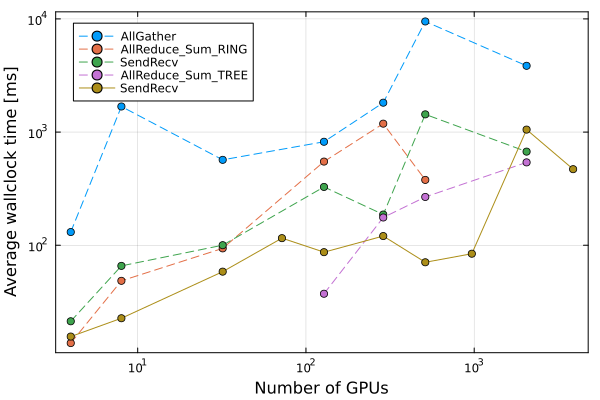

In [38]:
plot()
for k in nccl_metrics
    !(k in keys(run_metrics_ab)) && continue
    
    d = sort(run_metrics_ab[k], by=x->x.ngpu)
    x = map(x->x.ngpu, d)
    y = map(x->x.mean, d)
    plot!(
        x, y, label=metric_names[k],
        markershape=:circle, linestyle=:dash
    )
end

for k in nccl_metrics
    !(k in keys(run_metrics_co)) && continue
    
    d = sort(run_metrics_co[k], by=x->x.ngpu)
    x = map(x->x.ngpu, d)
    y = map(x->x.mean, d)
    plot!(
        x, y, label=metric_names[k],
        markershape=:circle, linestyle=:solid
    )
end

plot!(
    xaxis=:log, yaxis=:log,
    framestyle=:box,
    legend=:topleft,
    xlabel="Number of GPUs",
    ylabel="Average wallclock time [ms]"
)

In [ ]:
# TODO:
# 1. Possibly clean up the signal-to-noise by averaging over all MPI ranks (see TODO above)
# 2. What about these new "collectives":
#    a. Are they distict from the NCCL? Or do they wrap NCCL?
#    b. I suspect that they wrap the NCCL calls + some additional comms-related gubbins
# 3. Due dilligence: what metrics do we really care about?
# 4. (if time) analyze the Protobuf (XPlane) data => higher fidelity flops counters, etc